
🏠 PROPERTY ASSESSMENT FOR WEST SUSSEX

Price:
This property is priced broadly in line with the local market.

Affordability:
Your mortgage payments look comfortable relative to your income.

Financing:
The loan-to-value ratio is moderate, which is workable but still worth monitoring.

Market outlook:
Historically, this county has shown moderate long-term house price growth.
Based on the historical pattern in this county, the model suggests a moderate chance of price growth over 5 years.

Key numbers:
• Asking price: £450,000
• County median price: £375,000
• Typical county range: £275,000 – £530,500
• Monthly mortgage payment: £2,032
• Payment-to-income ratio: 27.1%
• Loan-to-value: 82.2%

5-year forecast:
• Average annual growth: 9.17%
• CAGR: 5.99%
• Volatility: 0.2669 (high volatility)
• Projected 5-year value (trend-based): £601,940
• Simulated median 5-year value: £513,201
• Simulated 5-year range (10th–90th percentile): £236,683 – £1,114,195
• Probability value is higher in 5 ye

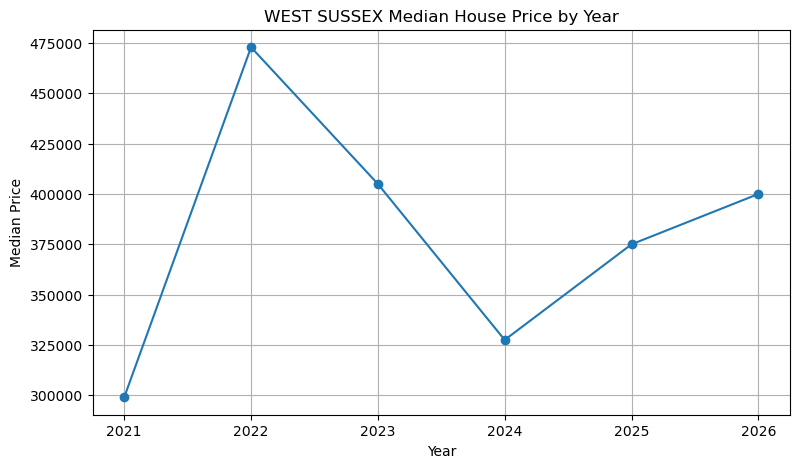

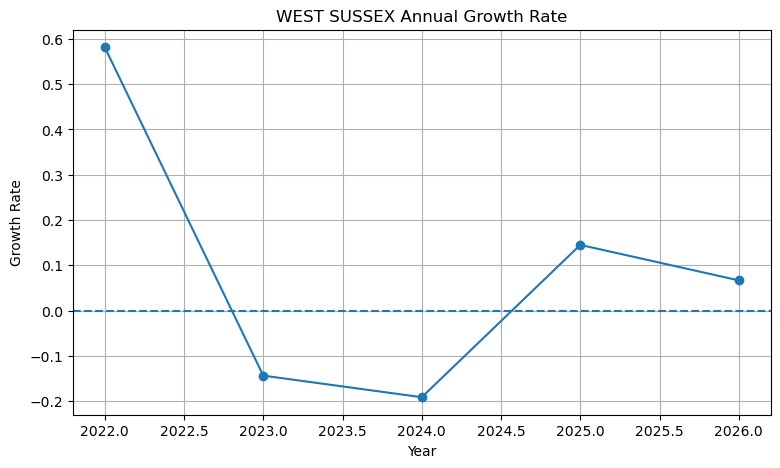

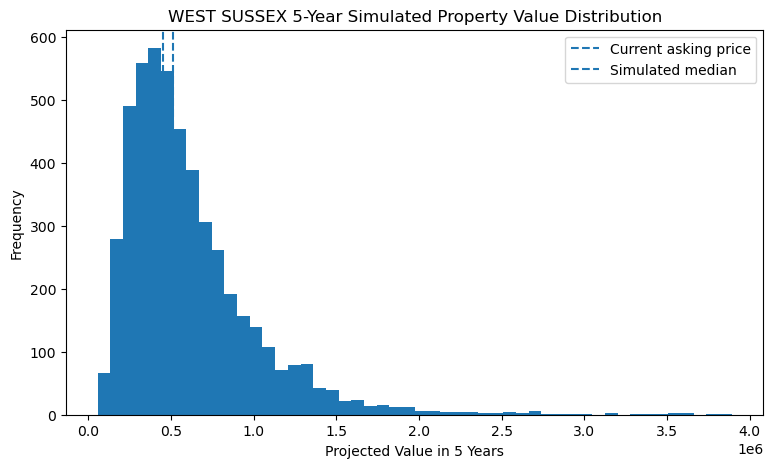

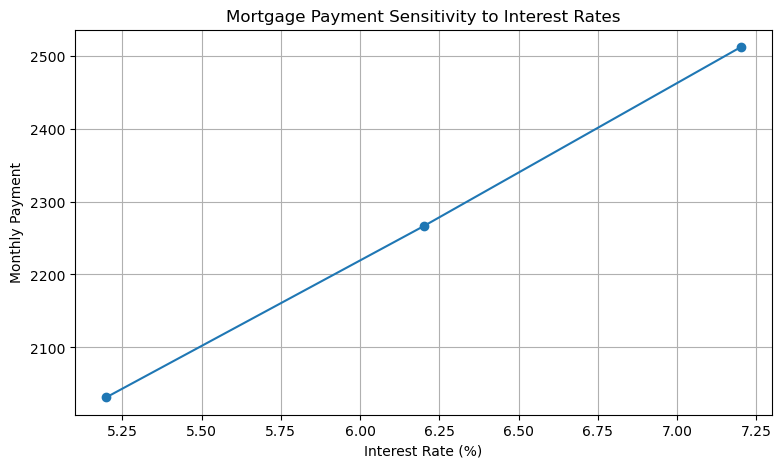

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD DATA
# ============================================================

file_path = "House Sales by County.xlsx"
data = pd.read_excel(file_path, sheet_name=None)

# ============================================================
# 2. CORE MODEL
# ============================================================

def analyse_house_advanced(
    data,
    county,
    asking_price,
    income,
    deposit,
    rate,
    years=30,
    forecast_years=5,
    simulations=5000
):
    """
    Advanced housing decision model.

    Inputs
    ------
    data : dict of DataFrames
        Excel sheets loaded with sheet_name=None
    county : str
        County selected by user
    asking_price : float
        House asking price
    income : float
        Annual household income
    deposit : float
        Deposit amount
    rate : float
        Mortgage interest rate (%)
    years : int
        Mortgage term in years
    forecast_years : int
        Projection horizon
    simulations : int
        Number of Monte Carlo simulations

    Returns
    -------
    dict
        Full model output for website/app use
    """

    # --------------------------------------------------------
    # A. COUNTY DATA PREP
    # --------------------------------------------------------
    if county not in data:
        raise ValueError(f"County '{county}' not found in dataset.")

    df = data[county].copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date", "price"]).copy()
    df["year"] = df["date"].dt.year
    df = df.sort_values("date")

    if len(df) < 10:
        raise ValueError(f"Not enough data for county '{county}'.")

    # --------------------------------------------------------
    # B. CURRENT MARKET VALUATION
    # --------------------------------------------------------
    median_price = df["price"].median()
    mean_price = df["price"].mean()
    lower_range = df["price"].quantile(0.25)
    upper_range = df["price"].quantile(0.75)
    p10 = df["price"].quantile(0.10)
    p90 = df["price"].quantile(0.90)
    sales_count = len(df)

    valuation_gap = (asking_price - median_price) / median_price

    if asking_price > upper_range:
        price_status = "overpriced"
    elif asking_price < lower_range:
        price_status = "cheap"
    else:
        price_status = "typical"

    # --------------------------------------------------------
    # C. FINANCING / MORTGAGE
    # --------------------------------------------------------
    loan = asking_price - deposit
    if loan <= 0:
        loan = 0

    monthly_rate = rate / 100 / 12
    months = years * 12

    if loan == 0:
        payment = 0
    elif monthly_rate == 0:
        payment = loan / months
    else:
        payment = loan * (monthly_rate * (1 + monthly_rate) ** months) / ((1 + monthly_rate) ** months - 1)

    monthly_income = income / 12
    ratio = payment / monthly_income if monthly_income > 0 else np.nan

    # Loan-to-value
    ltv = loan / asking_price if asking_price > 0 else np.nan

    if ltv > 0.90:
        ltv_status = "high leverage"
    elif ltv > 0.75:
        ltv_status = "moderate leverage"
    else:
        ltv_status = "low leverage"

    # Affordability band
    if ratio > 0.40:
        affordability = "high pressure"
    elif ratio > 0.30:
        affordability = "moderate pressure"
    else:
        affordability = "comfortable"

    # --------------------------------------------------------
    # D. YEARLY MARKET STATISTICS
    # --------------------------------------------------------
    yearly = (
        df.groupby("year")["price"]
        .agg(["median", "mean", "count"])
        .reset_index()
        .sort_values("year")
    )

    # Robust yearly series based on median
    yearly["annual_growth_rate"] = yearly["median"].pct_change()
    yearly["log_return"] = np.log(yearly["median"] / yearly["median"].shift(1))

    valid_returns = yearly["log_return"].dropna()

    if len(valid_returns) == 0:
        avg_growth = 0.0
        avg_log_return = 0.0
        volatility = 0.0
    else:
        avg_growth = yearly["annual_growth_rate"].dropna().mean()
        avg_log_return = valid_returns.mean()
        volatility = valid_returns.std(ddof=1) if len(valid_returns) > 1 else 0.0

    # CAGR
    first_price = yearly["median"].iloc[0]
    last_price = yearly["median"].iloc[-1]
    num_periods = max(len(yearly) - 1, 1)

    if first_price > 0 and num_periods > 0:
        cagr = (last_price / first_price) ** (1 / num_periods) - 1
    else:
        cagr = 0.0

    # Trend classification
    if cagr > 0.06:
        market_direction = "strong growth"
    elif cagr > 0.02:
        market_direction = "moderate growth"
    elif cagr > -0.02:
        market_direction = "broadly flat"
    else:
        market_direction = "declining"

    if volatility > 0.15:
        volatility_label = "high volatility"
    elif volatility > 0.07:
        volatility_label = "moderate volatility"
    else:
        volatility_label = "low volatility"

    # --------------------------------------------------------
    # E. 5-YEAR DETERMINISTIC PROJECTION
    # --------------------------------------------------------
    projected_5y_value = asking_price * np.exp(avg_log_return * forecast_years)
    projected_change_5y = (projected_5y_value - asking_price) / asking_price

    # --------------------------------------------------------
    # F. 5-YEAR MONTE CARLO FORECAST
    # --------------------------------------------------------
    # Geometric Brownian Motion based on county historical log return + volatility
    # This is still simple enough to interpret, but much richer than a single trend line.
    if volatility == 0:
        sim_values = np.repeat(projected_5y_value, simulations)
    else:
        z = np.random.normal(size=simulations)
        sim_values = asking_price * np.exp(
            (avg_log_return - 0.5 * volatility**2) * forecast_years
            + volatility * np.sqrt(forecast_years) * z
        )

    sim_median = np.median(sim_values)
    sim_mean = np.mean(sim_values)
    sim_p10 = np.percentile(sim_values, 10)
    sim_p25 = np.percentile(sim_values, 25)
    sim_p75 = np.percentile(sim_values, 75)
    sim_p90 = np.percentile(sim_values, 90)

    prob_price_up = np.mean(sim_values > asking_price)
    prob_price_down = np.mean(sim_values < asking_price)

    # --------------------------------------------------------
    # G. INTEREST RATE STRESS TEST
    # --------------------------------------------------------
    def stressed_payment(annual_rate):
        r = annual_rate / 100 / 12
        if loan == 0:
            return 0
        if r == 0:
            return loan / months
        return loan * (r * (1 + r) ** months) / ((1 + r) ** months - 1)

    payment_plus_1 = stressed_payment(rate + 1)
    payment_plus_2 = stressed_payment(rate + 2)

    ratio_plus_1 = payment_plus_1 / monthly_income if monthly_income > 0 else np.nan
    ratio_plus_2 = payment_plus_2 / monthly_income if monthly_income > 0 else np.nan

    # --------------------------------------------------------
    # H. SCORING MODEL
    # --------------------------------------------------------
    score = 100

    # Price fairness penalties
    if asking_price > p90:
        score -= 35
    elif asking_price > upper_range:
        score -= 25
    elif asking_price > median_price:
        score -= 10
    elif asking_price < lower_range:
        score += 5

    # Affordability penalties
    if ratio > 0.45:
        score -= 35
    elif ratio > 0.40:
        score -= 25
    elif ratio > 0.30:
        score -= 15
    elif ratio < 0.25:
        score += 5

    # LTV penalties
    if ltv > 0.95:
        score -= 20
    elif ltv > 0.90:
        score -= 15
    elif ltv > 0.80:
        score -= 8
    elif ltv < 0.60:
        score += 5

    # Market trend adjustment
    if cagr > 0.05:
        score += 10
    elif cagr > 0.02:
        score += 5
    elif cagr < -0.02:
        score -= 10

    # Volatility adjustment
    if volatility > 0.15:
        score -= 10
    elif volatility > 0.08:
        score -= 5

    # Forecast probability adjustment
    if prob_price_up > 0.75:
        score += 8
    elif prob_price_up > 0.60:
        score += 4
    elif prob_price_up < 0.40:
        score -= 8

    score = int(max(0, min(round(score), 100)))

    # --------------------------------------------------------
    # I. DECISION LABEL
    # --------------------------------------------------------
    if score >= 85:
        decision = "Strong buy"
    elif score >= 70:
        decision = "Reasonable buy"
    elif score >= 55:
        decision = "Caution"
    else:
        decision = "High risk"

    # --------------------------------------------------------
    # J. HUMAN-FRIENDLY WORDING
    # --------------------------------------------------------
    if price_status == "overpriced":
        price_text = "This property is priced above the typical range for the county, so there may be some risk of overpaying."
    elif price_status == "cheap":
        price_text = "This property is priced below the typical range for the county, which could indicate value, but it may also reflect condition or location factors."
    else:
        price_text = "This property is priced broadly in line with the local market."

    if affordability == "high pressure":
        affordability_text = "Your mortgage payments would take up a large share of your income, which could make the purchase financially stressful."
    elif affordability == "moderate pressure":
        affordability_text = "Your mortgage payments are manageable, but they would still take up a noticeable share of your income."
    else:
        affordability_text = "Your mortgage payments look comfortable relative to your income."

    if ltv_status == "high leverage":
        financing_text = "The loan-to-value ratio is high, which means you would be using a lot of leverage and taking on more financial risk."
    elif ltv_status == "moderate leverage":
        financing_text = "The loan-to-value ratio is moderate, which is workable but still worth monitoring."
    else:
        financing_text = "The loan-to-value ratio is relatively low, which gives you a stronger financial cushion."

    if market_direction == "strong growth":
        market_text = "Historically, this county has shown strong house price growth."
    elif market_direction == "moderate growth":
        market_text = "Historically, this county has shown moderate long-term house price growth."
    elif market_direction == "broadly flat":
        market_text = "Historically, this county has had a fairly flat housing market."
    else:
        market_text = "Historically, this county has shown signs of weakness or decline."

    if prob_price_up > 0.70:
        future_text = "Based on the historical pattern in this county, the model suggests a relatively strong chance that the property will be worth more in 5 years."
    elif prob_price_up > 0.55:
        future_text = "Based on the historical pattern in this county, the model suggests a moderate chance of price growth over 5 years."
    elif prob_price_up > 0.45:
        future_text = "The 5-year outlook looks mixed, with no very strong signal either way."
    else:
        future_text = "The model suggests there is a meaningful risk that the property may not gain value over the next 5 years."

    if score >= 85:
        score_text = "Overall, this looks like a strong purchase from both a market and affordability perspective."
    elif score >= 70:
        score_text = "Overall, this looks like a reasonable purchase, although there are some points to watch."
    elif score >= 55:
        score_text = "Overall, this purchase may be workable, but it comes with some important risks."
    else:
        score_text = "Overall, this looks like a risky purchase at the moment."

    # --------------------------------------------------------
    # K. WARNINGS
    # --------------------------------------------------------
    warnings = []

    if asking_price > upper_range:
        warnings.append("Price is above the county's typical upper range.")
    if ratio > 0.40:
        warnings.append("Mortgage payments are high relative to income.")
    if ltv > 0.90:
        warnings.append("Loan-to-value is very high.")
    if volatility > 0.15:
        warnings.append("County market has been highly volatile.")
    if prob_price_down > 0.50:
        warnings.append("Model suggests more than a 50% chance the property could be worth less than today's price in 5 years.")

    # --------------------------------------------------------
    # L. PRETTY SUMMARY
    # --------------------------------------------------------
    summary = f"""
🏠 PROPERTY ASSESSMENT FOR {county}

Price:
{price_text}

Affordability:
{affordability_text}

Financing:
{financing_text}

Market outlook:
{market_text}
{future_text}

Key numbers:
• Asking price: £{asking_price:,.0f}
• County median price: £{median_price:,.0f}
• Typical county range: £{lower_range:,.0f} – £{upper_range:,.0f}
• Monthly mortgage payment: £{payment:,.0f}
• Payment-to-income ratio: {ratio:.1%}
• Loan-to-value: {ltv:.1%}

5-year forecast:
• Average annual growth: {avg_growth:.2%}
• CAGR: {cagr:.2%}
• Volatility: {volatility:.4f} ({volatility_label})
• Projected 5-year value (trend-based): £{projected_5y_value:,.0f}
• Simulated median 5-year value: £{sim_median:,.0f}
• Simulated 5-year range (10th–90th percentile): £{sim_p10:,.0f} – £{sim_p90:,.0f}
• Probability value is higher in 5 years: {prob_price_up:.1%}
• Probability value is lower in 5 years: {prob_price_down:.1%}

Rate stress test:
• Payment at current rate ({rate:.1f}%): £{payment:,.0f}
• Payment if rate rises to {rate+1:.1f}%: £{payment_plus_1:,.0f}
• Payment if rate rises to {rate+2:.1f}%: £{payment_plus_2:,.0f}

⭐ Buyer score: {score}/100
🧠 Final view: {score_text}
"""

    return {
        "decision": decision,
        "score": score,
        "summary": summary,
        "warnings": warnings,
        "sales_count": sales_count,
        "median_price": median_price,
        "mean_price": mean_price,
        "lower_range": lower_range,
        "upper_range": upper_range,
        "price_status": price_status,
        "valuation_gap": valuation_gap,
        "loan": loan,
        "monthly_payment": payment,
        "payment_ratio": ratio,
        "ltv": ltv,
        "ltv_status": ltv_status,
        "affordability": affordability,
        "avg_growth": avg_growth,
        "avg_log_return": avg_log_return,
        "volatility": volatility,
        "cagr": cagr,
        "market_direction": market_direction,
        "volatility_label": volatility_label,
        "projected_5y_value": projected_5y_value,
        "projected_change_5y": projected_change_5y,
        "simulated_values": sim_values,
        "sim_median": sim_median,
        "sim_mean": sim_mean,
        "sim_p10": sim_p10,
        "sim_p25": sim_p25,
        "sim_p75": sim_p75,
        "sim_p90": sim_p90,
        "prob_price_up": prob_price_up,
        "prob_price_down": prob_price_down,
        "payment_plus_1": payment_plus_1,
        "payment_plus_2": payment_plus_2,
        "ratio_plus_1": ratio_plus_1,
        "ratio_plus_2": ratio_plus_2,
        "yearly_data": yearly
    }

# ============================================================
# 3. USER INPUTS (CHANGE THESE)
# ============================================================

county = "WEST SUSSEX"
asking_price = 450000
income = 90000
deposit = 80000
rate = 5.2
years = 30
forecast_years = 5
simulations = 5000

# ============================================================
# 4. RUN MODEL
# ============================================================

result = analyse_house_advanced(
    data=data,
    county=county,
    asking_price=asking_price,
    income=income,
    deposit=deposit,
    rate=rate,
    years=years,
    forecast_years=forecast_years,
    simulations=simulations
)

print(result["summary"])

print("\n⚠ WARNINGS")
print("-----------")
if result["warnings"]:
    for w in result["warnings"]:
        print("-", w)
else:
    print("No major warnings detected.")

# ============================================================
# 5. CHARTS
# ============================================================

yearly = result["yearly_data"]

# Yearly median price chart
plt.figure(figsize=(9, 5))
plt.plot(yearly["year"], yearly["median"], marker="o")
plt.title(f"{county} Median House Price by Year")
plt.xlabel("Year")
plt.ylabel("Median Price")
plt.grid(True)
plt.show()

# Annual growth rate chart
plt.figure(figsize=(9, 5))
plt.plot(yearly["year"], yearly["annual_growth_rate"], marker="o")
plt.axhline(0, linestyle="--")
plt.title(f"{county} Annual Growth Rate")
plt.xlabel("Year")
plt.ylabel("Growth Rate")
plt.grid(True)
plt.show()

# 5-year forecast distribution
plt.figure(figsize=(9, 5))
plt.hist(result["simulated_values"], bins=50)
plt.axvline(asking_price, linestyle="--", label="Current asking price")
plt.axvline(result["sim_median"], linestyle="--", label="Simulated median")
plt.title(f"{county} 5-Year Simulated Property Value Distribution")
plt.xlabel("Projected Value in 5 Years")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Mortgage rate stress chart
stress_rates = [rate, rate + 1, rate + 2]
stress_payments = [result["monthly_payment"], result["payment_plus_1"], result["payment_plus_2"]]

plt.figure(figsize=(9, 5))
plt.plot(stress_rates, stress_payments, marker="o")
plt.title("Mortgage Payment Sensitivity to Interest Rates")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Monthly Payment")
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# EXPORT COUNTY STATS TO county_stats.js
# Run this cell after loading data to regenerate the web stats.
# ============================================================

import json as _json
import numpy as _np

def _county_market_stats(df_raw):
    df = df_raw.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date', 'price']).copy()
    df['year'] = df['date'].dt.year
    df = df.sort_values('date')
    if len(df) < 10:
        return None

    median_price = float(df['price'].median())
    q25   = float(df['price'].quantile(0.25))
    q75   = float(df['price'].quantile(0.75))
    count = int(len(df))

    yearly = (
        df.groupby('year')['price']
        .median()
        .reset_index()
        .rename(columns={'price': 'median'})
        .sort_values('year')
    )
    yearly['log_return']   = _np.log(yearly['median'] / yearly['median'].shift(1))
    yearly['annual_growth'] = yearly['median'].pct_change()

    valid = yearly['log_return'].dropna()
    if len(valid) == 0:
        avg_log_return = cagr = volatility = avg_growth = 0.0
    else:
        avg_log_return = float(valid.mean())
        volatility     = float(valid.std(ddof=1)) if len(valid) > 1 else 0.0
        avg_growth     = float(yearly['annual_growth'].dropna().mean())
        fp = float(yearly['median'].iloc[0])
        lp = float(yearly['median'].iloc[-1])
        n  = max(len(yearly) - 1, 1)
        cagr = float((lp / fp) ** (1 / n) - 1) if fp > 0 else 0.0

    if   cagr > 0.06:  market_direction = 'strong growth'
    elif cagr > 0.02:  market_direction = 'moderate growth'
    elif cagr > -0.02: market_direction = 'broadly flat'
    else:              market_direction = 'declining'

    if   volatility > 0.15: volatility_label = 'high volatility'
    elif volatility > 0.07: volatility_label = 'moderate volatility'
    else:                   volatility_label = 'low volatility'

    yearly_trend = [
        {'year': int(r['year']), 'median': round(float(r['median']), 0)}
        for _, r in yearly.iterrows()
    ]

    return {
        'median':          round(median_price, 0),
        'q25':             round(q25, 0),
        'q75':             round(q75, 0),
        'count':           count,
        'cagr':            round(cagr, 4),
        'avg_log_return':  round(avg_log_return, 4),
        'volatility':      round(volatility, 4),
        'avg_growth':      round(avg_growth, 4),
        'market_direction': market_direction,
        'volatility_label': volatility_label,
        'yearly':          yearly_trend,
    }

all_stats, skipped = {}, []
for county_name, df_sheet in data.items():
    stats = _county_market_stats(df_sheet)
    if stats is not None:
        all_stats[county_name] = stats
    else:
        skipped.append(county_name)

if skipped:
    print(f'Skipped {len(skipped)} counties (not enough data): {skipped}')

js_out = 'const COUNTY_STATS = ' + _json.dumps(all_stats, indent=2) + ';\n'
with open('county_stats.js', 'w') as f:
    f.write(js_out)

print(f'✅  Exported {len(all_stats)} counties to county_stats.js')
print('    Reload housing_analyser_web.html in your browser to see updated data.')
